# 06 Final Model Evaluation

This notebook loads `models/best_model.joblib` and evaluates the saved model pipeline on the same leakage-safe held-out test split used during predictive modeling.

Outputs:

- `reports/final_model_metrics.csv`
- `reports/threshold_analysis.csv`
- Figures saved under `reports/figures/`

In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold, train_test_split

# Resolve paths robustly whether the notebook is run from the repository root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data' / 'CardiacPatientData.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import add_clinical_features

DATA_PATH = PROJECT_ROOT / 'data' / 'CardiacPatientData.csv'
MODEL_PATH = PROJECT_ROOT / 'models' / 'best_model.joblib'
REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
FINAL_METRICS_PATH = REPORTS_DIR / 'final_model_metrics.csv'
THRESHOLD_ANALYSIS_PATH = REPORTS_DIR / 'threshold_analysis.csv'

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20
POS_LABEL = 1
sns.set_theme(style='whitegrid')

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f'Missing saved model: {MODEL_PATH.relative_to(PROJECT_ROOT)}. '
        'Run notebooks/05_predictive_modeling.ipynb first to create it.'
    )

## Load data, recreate the held out test set, and score the saved model

The split logic mirrors `notebooks/05_predictive_modeling.ipynb`: repeated `ID` values are kept together with `StratifiedGroupKFold`; otherwise, a stratified row-wise split is used. Clinical features are deterministic row-level features and are added after splitting. `ID` is removed before prediction to avoid identifier leakage.

In [2]:
df = pd.read_csv(DATA_PATH)
model = joblib.load(MODEL_PATH)

id_counts = df['ID'].value_counts()
ids_repeat = bool((id_counts > 1).any())
X_raw = df.drop(columns=['Outcome'])
y = df['Outcome'].astype(int)

if ids_repeat:
    holdout_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    train_idx, test_idx = next(holdout_splitter.split(X_raw, y, groups=df['ID']))
    split_strategy = 'StratifiedGroupKFold by patient ID'
else:
    train_idx, test_idx = train_test_split(
        np.arange(len(df)),
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    split_strategy = 'Stratified train/test split'

test_raw = df.iloc[test_idx].copy()
test_features = add_clinical_features(test_raw.drop(columns=['Outcome']))
y_test = test_raw['Outcome'].astype(int)
X_test = test_features.drop(columns=['ID'])

categorical_features = [
    'Gender',
    'Alcoholic',
    'Smoke',
    'FHCD',
    'TriageScore',
    'age_band',
    'gcs_severity',
    'hypoxemia_flag',
    'sodium_abnormal_flag',
    'potassium_abnormal_flag',
    'chloride_abnormal_flag',
    'urea_abnormal_flag',
    'creatinine_abnormal_flag',
]
categorical_features = [col for col in categorical_features if col in X_test.columns]
X_test_model = X_test.copy()
for col in categorical_features:
    X_test_model[col] = X_test_model[col].astype('object').where(X_test_model[col].notna(), np.nan)

y_score = model.predict_proba(X_test_model)[:, 1]

print(f'Model loaded from: {MODEL_PATH.relative_to(PROJECT_ROOT)}')
print(f'Split strategy: {split_strategy}')
print(f'Test rows: {len(test_raw):,}')
print(f'Test event rate: {y_test.mean():.3f}')
print(f'Score range: {y_score.min():.3f} to {y_score.max():.3f}')

Model loaded from: models\best_model.joblib
Split strategy: StratifiedGroupKFold by patient ID
Test rows: 1,080
Test event rate: 0.881
Score range: 0.121 to 0.976


## Threshold analysis

The table below evaluates clinically relevant tradeoffs across probability thresholds. Sensitivity is prioritized for a high-risk screening flag, while specificity and PPV quantify the false alarm burden.

In [3]:
def binary_threshold_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    flagged = int(y_pred.sum())
    return {
        'threshold': threshold,
        'sensitivity': recall_score(y_true, y_pred, zero_division=0),
        'specificity': tn / (tn + fp) if (tn + fp) else np.nan,
        'ppv': precision_score(y_true, y_pred, zero_division=0),
        'npv': tn / (tn + fn) if (tn + fn) else np.nan,
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'flagged_high_risk': flagged,
        'flagged_high_risk_pct': flagged / len(y_true),
        'true_negative': int(tn),
        'false_positive': int(fp),
        'false_negative': int(fn),
        'true_positive': int(tp),
    }

thresholds = np.round(np.arange(0.05, 0.96, 0.05), 2)
threshold_df = pd.DataFrame([binary_threshold_metrics(y_test, y_score, threshold) for threshold in thresholds])

# Clinical threshold rule: preserve at least 90% sensitivity when possible, then choose the highest
# threshold among eligible candidates to limit false alarms and alert fatigue.
sensitive_candidates = threshold_df[threshold_df['sensitivity'] >= 0.90].copy()
if len(sensitive_candidates):
    recommended_row = sensitive_candidates.sort_values(
        ['threshold', 'specificity', 'ppv'], ascending=[False, False, False]
    ).iloc[0]
    recommendation_rule = 'highest threshold with sensitivity >= 0.90 to limit false alarms'
else:
    recommended_row = threshold_df.sort_values(['f1', 'sensitivity'], ascending=[False, False]).iloc[0]
    recommendation_rule = 'highest F1 because no threshold achieved sensitivity >= 0.90'

recommended_threshold = float(recommended_row['threshold'])
threshold_df['recommended'] = threshold_df['threshold'].eq(recommended_threshold)
threshold_df.to_csv(THRESHOLD_ANALYSIS_PATH, index=False)

print(f'Saved threshold analysis to: {THRESHOLD_ANALYSIS_PATH.relative_to(PROJECT_ROOT)}')
print(f'Recommended threshold: {recommended_threshold:.2f} ({recommendation_rule})')
display(threshold_df.style.format({
    'threshold': '{:.2f}',
    'sensitivity': '{:.3f}',
    'specificity': '{:.3f}',
    'ppv': '{:.3f}',
    'npv': '{:.3f}',
    'f1': '{:.3f}',
    'flagged_high_risk_pct': '{:.1%}',
}))

Saved threshold analysis to: reports\threshold_analysis.csv
Recommended threshold: 0.70 (highest threshold with sensitivity >= 0.90 to limit false alarms)


,threshold,sensitivity,specificity,ppv,npv,f1,flagged_high_risk,flagged_high_risk_pct,true_negative,false_positive,false_negative,true_positive,recommended
0,0.05,1.000,0.000,0.881,nan,0.937,1080,100.0%,0,128,0,952,False
1,0.10,1.000,0.000,0.881,nan,0.937,1080,100.0%,0,128,0,952,False
2,0.15,0.999,0.000,0.881,0.000,0.936,1079,99.9%,0,128,1,951,False
3,0.20,0.999,0.016,0.883,0.667,0.937,1077,99.7%,2,126,1,951,False
4,0.25,0.997,0.016,0.883,0.400,0.936,1075,99.5%,2,126,3,949,False
5,0.30,0.995,0.125,0.894,0.762,0.942,1059,98.1%,16,112,5,947,False
6,0.35,0.991,0.125,0.894,0.640,0.940,1055,97.7%,16,112,9,943,False
7,0.40,0.988,0.234,0.906,0.732,0.945,1039,96.2%,30,98,11,941,False
8,0.45,0.980,0.562,0.943,0.791,0.961,989,91.6%,72,56,19,933,False
9,0.50,0.978,0.570,0.944,0.777,0.961,986,91.3%,73,55,21,931,False


## Discrimination curves

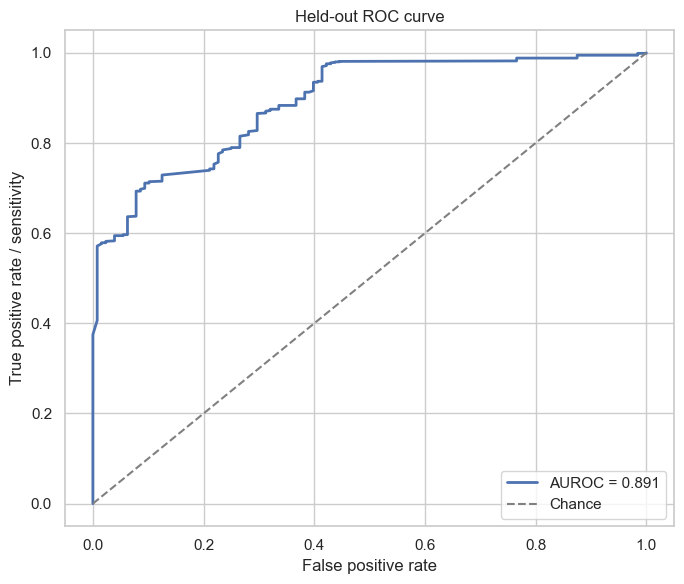

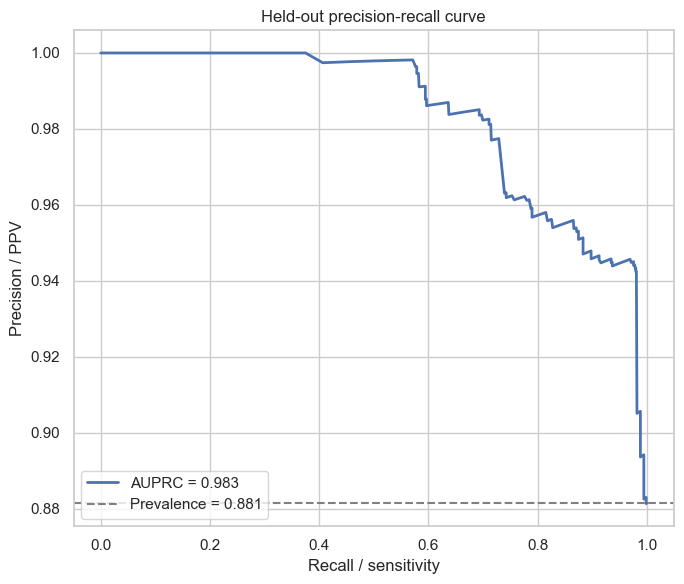

Saved ROC curve to: reports\figures\final_model_roc_curve.png
Saved precision-recall curve to: reports\figures\final_model_precision_recall_curve.png


In [4]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_score, pos_label=POS_LABEL)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_score, pos_label=POS_LABEL)
auroc = roc_auc_score(y_test, y_score)
auprc = average_precision_score(y_test, y_score)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f'AUROC = {auroc:.3f}', linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate / sensitivity')
ax.set_title('Held-out ROC curve')
ax.legend(loc='lower right')
fig.tight_layout()
roc_path = FIGURES_DIR / 'final_model_roc_curve.png'
fig.savefig(roc_path, dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall, precision, label=f'AUPRC = {auprc:.3f}', linewidth=2)
ax.axhline(y_test.mean(), linestyle='--', color='gray', label=f'Prevalence = {y_test.mean():.3f}')
ax.set_xlabel('Recall / sensitivity')
ax.set_ylabel('Precision / PPV')
ax.set_title('Held-out precision-recall curve')
ax.legend(loc='lower left')
fig.tight_layout()
pr_path = FIGURES_DIR / 'final_model_precision_recall_curve.png'
fig.savefig(pr_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved ROC curve to: {roc_path.relative_to(PROJECT_ROOT)}')
print(f'Saved precision-recall curve to: {pr_path.relative_to(PROJECT_ROOT)}')

## Calibration assessment

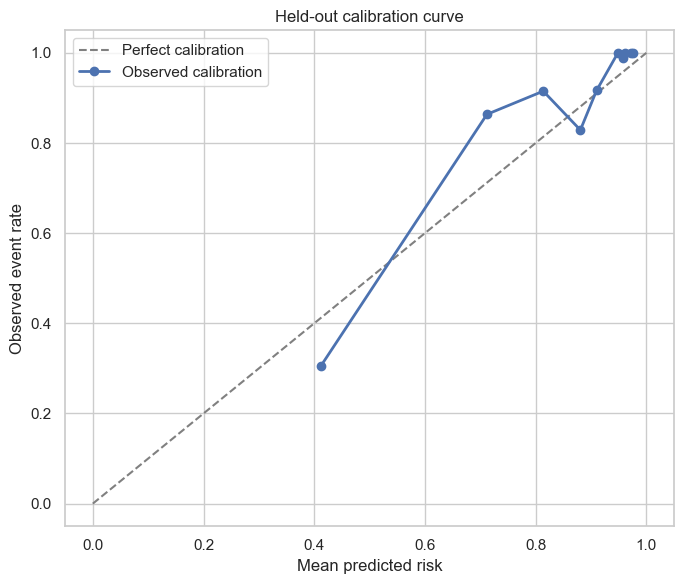

Brier score: 0.0700
Calibration intercept: -0.0835
Calibration slope: 1.3607
Saved calibration curve to: reports\figures\final_model_calibration_curve.png


In [5]:
brier = brier_score_loss(y_test, y_score, pos_label=POS_LABEL)
prob_true, prob_pred = calibration_curve(y_test, y_score, n_bins=10, strategy='quantile')

eps = np.finfo(float).eps
logit_scores = np.log(np.clip(y_score, eps, 1 - eps) / (1 - np.clip(y_score, eps, 1 - eps)))
calibration_model = sm.Logit(y_test, sm.add_constant(logit_scores)).fit(disp=False)
calibration_intercept = float(calibration_model.params.iloc[0])
calibration_slope = float(calibration_model.params.iloc[1])

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
ax.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Observed calibration')
ax.set_xlabel('Mean predicted risk')
ax.set_ylabel('Observed event rate')
ax.set_title('Held-out calibration curve')
ax.legend(loc='upper left')
fig.tight_layout()
calibration_path = FIGURES_DIR / 'final_model_calibration_curve.png'
fig.savefig(calibration_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Brier score: {brier:.4f}')
print(f'Calibration intercept: {calibration_intercept:.4f}')
print(f'Calibration slope: {calibration_slope:.4f}')
print(f'Saved calibration curve to: {calibration_path.relative_to(PROJECT_ROOT)}')

## Confusion matrices at multiple thresholds

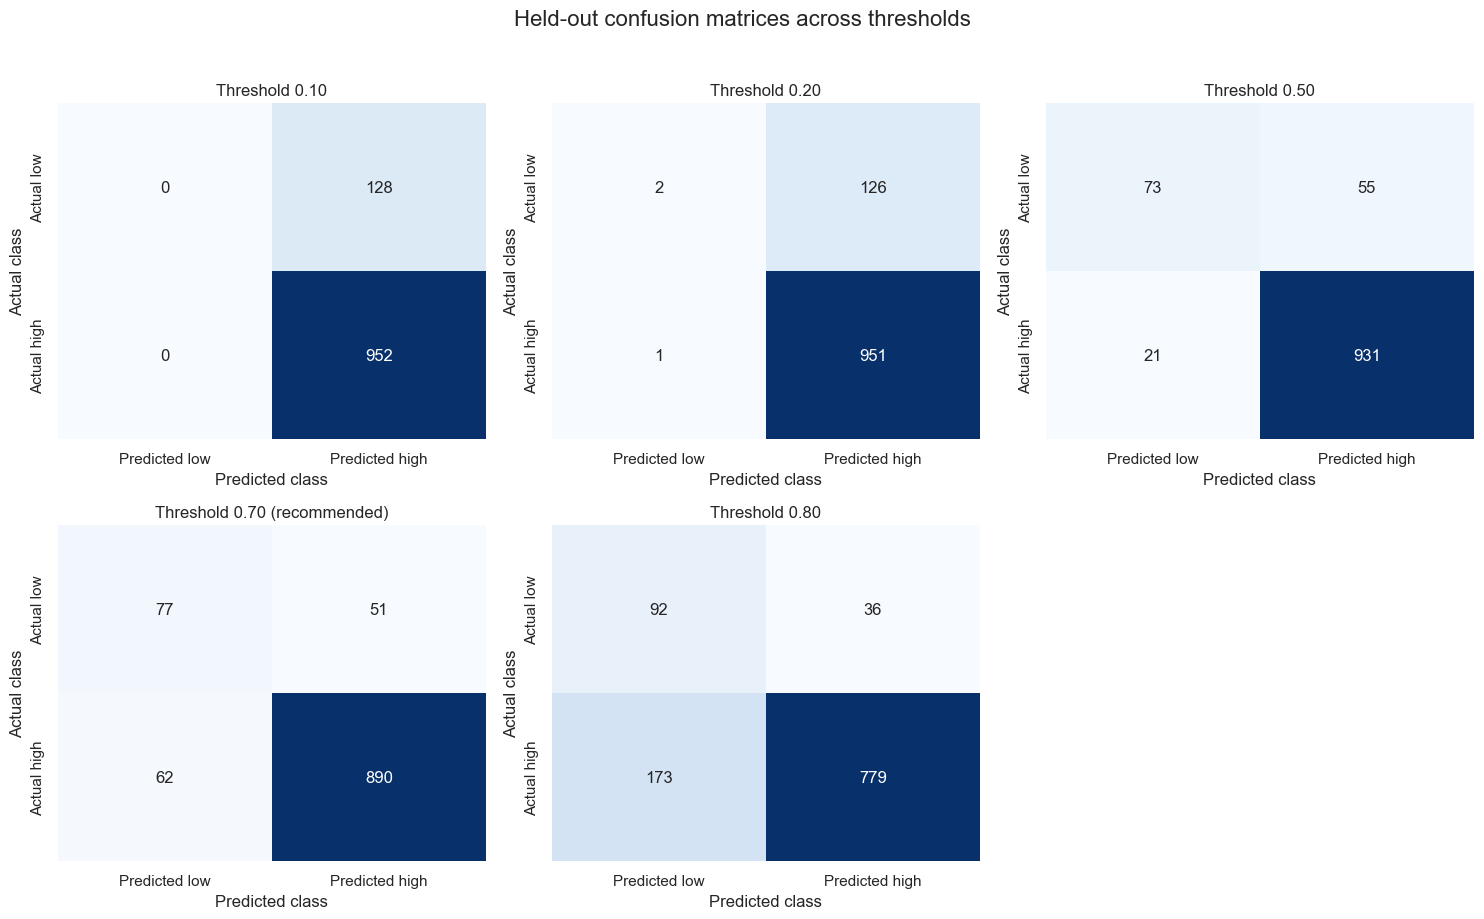

Saved confusion matrices to: reports\figures\final_model_confusion_matrices.png


In [6]:
thresholds_to_plot = sorted(set([0.10, 0.20, recommended_threshold, 0.50, 0.80]))
n_cols = min(3, len(thresholds_to_plot))
n_rows = int(np.ceil(len(thresholds_to_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, threshold in zip(axes, thresholds_to_plot):
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Predicted low', 'Predicted high'],
        yticklabels=['Actual low', 'Actual high'],
        ax=ax,
    )
    title_suffix = ' (recommended)' if np.isclose(threshold, recommended_threshold) else ''
    ax.set_title(f'Threshold {threshold:.2f}{title_suffix}')
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('Actual class')

for ax in axes[len(thresholds_to_plot):]:
    ax.axis('off')

fig.suptitle('Held-out confusion matrices across thresholds', y=1.02, fontsize=16)
fig.tight_layout()
confusion_path = FIGURES_DIR / 'final_model_confusion_matrices.png'
fig.savefig(confusion_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved confusion matrices to: {confusion_path.relative_to(PROJECT_ROOT)}')

## Final metrics and clinical threshold recommendation

In [7]:
rec_metrics = recommended_row.to_dict()
final_metrics = {
    'model_path': str(MODEL_PATH.relative_to(PROJECT_ROOT)),
    'split_strategy': split_strategy,
    'test_rows': len(test_raw),
    'test_event_rate': y_test.mean(),
    'auroc': auroc,
    'auprc': auprc,
    'brier_score': brier,
    'calibration_intercept': calibration_intercept,
    'calibration_slope': calibration_slope,
    'recommended_threshold': recommended_threshold,
    'recommendation_rule': recommendation_rule,
    'recommended_sensitivity': rec_metrics['sensitivity'],
    'recommended_specificity': rec_metrics['specificity'],
    'recommended_ppv': rec_metrics['ppv'],
    'recommended_npv': rec_metrics['npv'],
    'recommended_f1': rec_metrics['f1'],
    'recommended_flagged_high_risk': int(rec_metrics['flagged_high_risk']),
    'recommended_flagged_high_risk_pct': rec_metrics['flagged_high_risk_pct'],
    'recommended_true_negative': int(rec_metrics['true_negative']),
    'recommended_false_positive': int(rec_metrics['false_positive']),
    'recommended_false_negative': int(rec_metrics['false_negative']),
    'recommended_true_positive': int(rec_metrics['true_positive']),
}

final_metrics_df = pd.DataFrame([final_metrics])
final_metrics_df.to_csv(FINAL_METRICS_PATH, index=False)

print(f'Saved final metrics to: {FINAL_METRICS_PATH.relative_to(PROJECT_ROOT)}')
display(final_metrics_df.T.rename(columns={0: 'value'}))

recommendation_text = (
    f"Recommend using a probability threshold of {recommended_threshold:.2f}. "
    f"This threshold follows the rule '{recommendation_rule}' and identifies "
    f"{int(rec_metrics['flagged_high_risk'])} of {len(y_test)} held-out patients "
    f"({rec_metrics['flagged_high_risk_pct']:.1%}) as high risk. It achieves sensitivity "
    f"{rec_metrics['sensitivity']:.3f} and NPV {rec_metrics['npv']:.3f}, supporting the "
    f"clinical goal of catching most high-risk patients, while specificity "
    f"{rec_metrics['specificity']:.3f} and PPV {rec_metrics['ppv']:.3f} quantify the "
    'remaining false-alarm burden. This threshold should be validated with clinicians and, '
    'ideally, prospectively recalibrated before operational use.'
)
print(recommendation_text)

Saved final metrics to: reports\final_model_metrics.csv


,value
model_path,models\best_model.joblib
split_strategy,StratifiedGroupKFold by patient ID
test_rows,1080
test_event_rate,0.881481
auroc,0.891442
auprc,0.983477
brier_score,0.070005
calibration_intercept,-0.083491
calibration_slope,1.360682
recommended_threshold,0.7


Recommend using a probability threshold of 0.70. This threshold follows the rule 'highest threshold with sensitivity >= 0.90 to limit false alarms' and identifies 941 of 1080 held-out patients (87.1%) as high risk. It achieves sensitivity 0.935 and NPV 0.554, supporting the clinical goal of catching most high-risk patients, while specificity 0.602 and PPV 0.946 quantify the remaining false-alarm burden. This threshold should be validated with clinicians and, ideally, prospectively recalibrated before operational use.


## Conclusion

This notebook evaluated the final model on the held-out test set to measure how well it performs on unseen patient data. The evaluation focused on discrimination, calibration, and threshold selection. AUROC and AUPRC showed how well the model separated higher-risk and lower-risk patients, while the Brier score and calibration curve assessed how reliable the predicted probabilities were. The threshold analysis was especially important because a cardiac risk model should prioritize catching high-risk patients rather than relying on the default 0.50 cutoff.

This notebook provides a final check of model performance and shows how the model could be used as a screening tool. Before any clinical use, the model would still need external validation, subgroup testing, and clinical review.